In [194]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min';Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# dx = 250 m; Np = 1M; Nt = 5 min
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
res='1km';t_res='5min';Np_str='1e6'

In [195]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

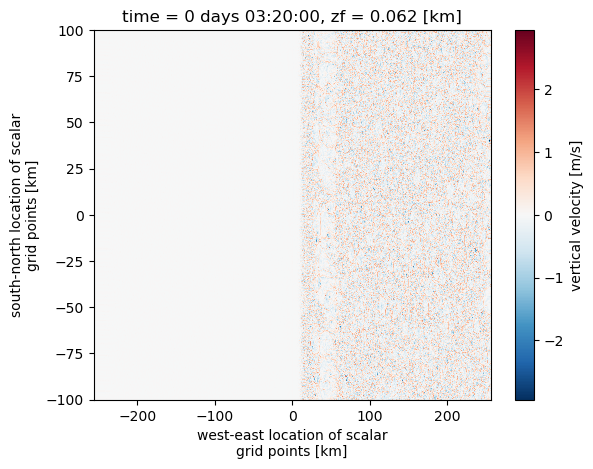

In [391]:
data['w'].isel(time=200,zf=1).plot()

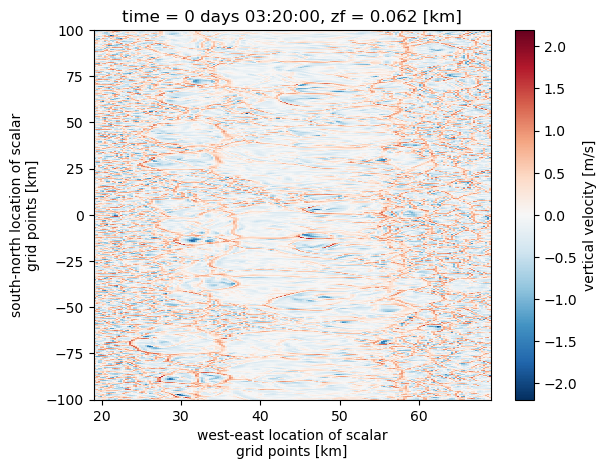

In [392]:
data['w'].isel(time=200,zf=1,xh=slice(1100,1300)).plot()

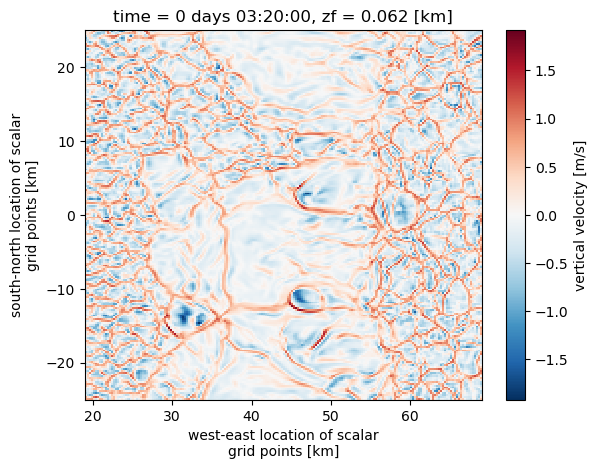

In [393]:
data['w'].isel(time=200,zf=1,xh=slice(1100,1300),yh=slice(300,500)).plot()

In [196]:
###########################################################################
#MASS FLUX CALCULATIONS

In [394]:
# If velocity vel[i] > 0 (flow going from left to right):
# Use the density value from the cell immediately to the left of the face, which is rho[i-1].
# This is because the fluid moving through face i comes from the left side.

# If velocity vel[i] ≤ 0 (flow going from right to left):
# Use the density value from the cell immediately to the right of the face, which is rho[i].
# This is because the fluid moving through face i comes from the right side.




import numpy as np

def upwind_mass_flux(rho, vel, axis):
    # rho shape: (..., N, ...)
    # vel shape: (..., N+1, ...)
    # axis: axis along which velocity is staggered and upwind is computed
    
    # Move the staggered axis to the last for easy indexing
    rho_moved = np.moveaxis(rho.data, axis, -1)  # shape (..., N)
    vel_moved = np.moveaxis(vel.data, axis, -1)  # shape (..., N+1)
    
    N = rho_moved.shape[-1]
    flux = np.empty_like(vel_moved)
    
    # For interior faces 1..N-1:
    # flux[i] = vel[i] * (rho[i-1] if vel[i] > 0 else rho[i])
    
    # First face (i=0) boundary: could set flux to 0 or same scheme with clamped indices
    # Last face (i=N) boundary: similarly
    
    # Here let's zero flux at boundaries for simplicity
    flux[..., 0] = 0
    flux[..., -1] = 0
    
    # Interior faces
    for i in range(1, N):
        upwind_rho = np.where(vel_moved[..., i] > 0,
                              rho_moved[..., i-1],
                              rho_moved[..., i])
        flux[..., i] = vel_moved[..., i] * upwind_rho
    
    # Move axis back to original position
    flux = np.moveaxis(flux, -1, axis)
    return flux


In [396]:
def MakeSingleVelocityPlotUpwind(data, t, velocity_name,z_slice,y_slice,x_slice):
    """
    Plot upwind horizontal average of rho * velocity at a single timestep,
    subsetting according to the staggered grid layout for each velocity component.
    
    Parameters:
    - data: xarray Dataset with 'rho', velocity variable, and 'zh'
    - t: integer index of the time step
    - velocity_name: 'u', 'v', or 'w'
    """

    # Grid dim mapping for staggered velocity fields
    vel_dims = {
        'u': {'z': 'zh', 'y': 'yh', 'x': 'xf', 'axis': 2},
        'v': {'z': 'zh', 'y': 'yf', 'x': 'xh', 'axis': 1},
        'w': {'z': 'zf', 'y': 'yh', 'x': 'xh', 'axis': 0}
    }
    
    dims = vel_dims[velocity_name]
    
    # Subset velocity and rho appropriately
    vel = data[velocity_name].isel(
        time=t,
        **{dims['y']: y_slice, dims['x']: x_slice}
    )
    
    rho = data['rho'].isel(
        time=t,
        yh=y_slice, xh=x_slice
    )
    
    flux = upwind_mass_flux(rho, vel, axis=dims['axis'])
    horiz_mean = np.mean(flux.data,axis=(1,2))
    return horiz_mean

y_slice = slice(300, 500)
x_slice = slice(1100, 1300)

In [397]:
velocity_name = 'w'
w_horiz_mean = MakeSingleVelocityPlotUpwind(data, t, velocity_name, z_slice, y_slice, x_slice)

#####
winterp = data['w'].isel(time=t, yh=y_slice, xh=x_slice).interp(zf=data['zh'])
rho = data['rho'].isel(time=t, yh=y_slice, xh=x_slice)
product = (winterp * rho).data
#####

velocity_name = 'v'
v_horiz_mean = MakeSingleVelocityPlotUpwind(data, t, velocity_name, z_slice, y_slice, x_slice)

velocity_name = 'u'
u_horiz_mean = MakeSingleVelocityPlotUpwind(data, t, velocity_name, z_slice, y_slice, x_slice)

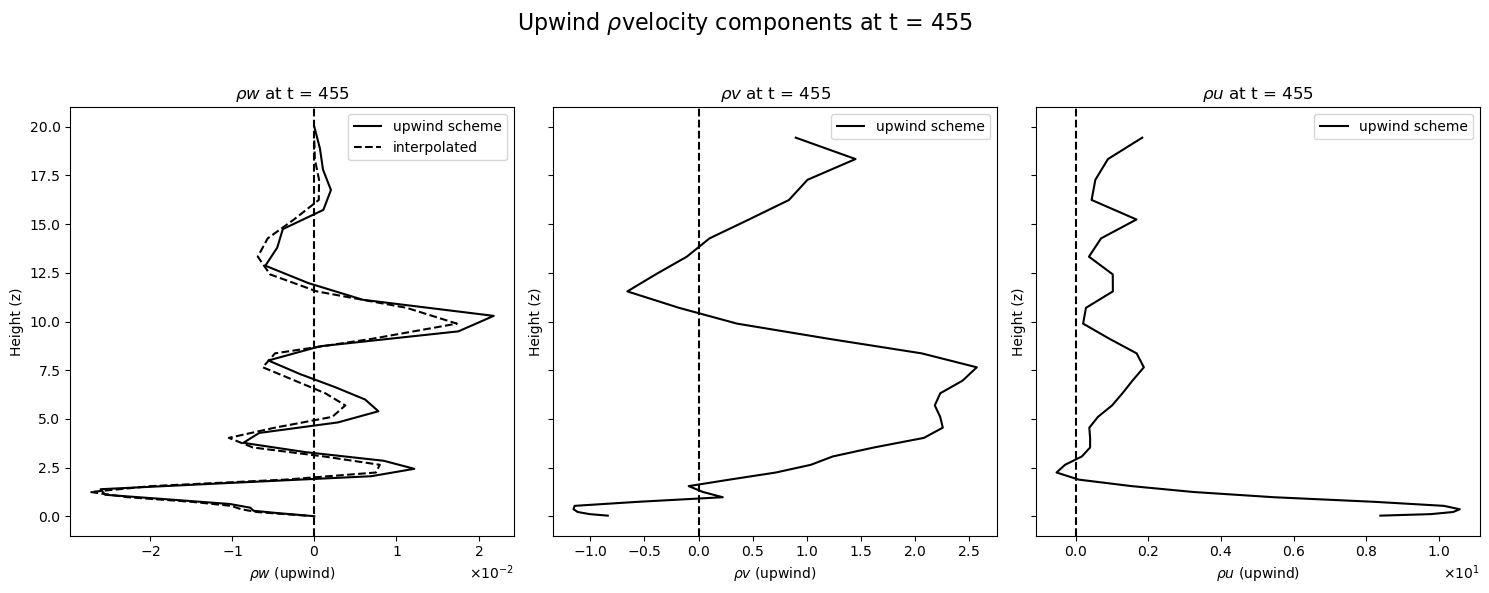

In [398]:
def plot_rho_w_ax():

    zh_coord = data['zh']
    zf_coord = data['zf']

    ax = plt.gca()
    ax.plot(w_horiz_mean, zf_coord, color='black', label='upwind scheme')
    ax.plot(np.mean(product, axis=(1, 2)), zh_coord, color='black', linestyle='dashed', label='interpolated')
    ax.axvline(0, color='black', linestyle='dashed')
    ax.set_ylabel("Height (z)")
    ax.set_xlabel(r"$\rho w$ (upwind)")
    ax.set_title(f"$\\rho w$ at t = {t}")
    apply_scientific_notation([ax])
    ax.legend()
    return ax


def plot_rho_v_ax():

    zh_coord = data['zh']

    ax = plt.gca()
    ax.plot(v_horiz_mean, zh_coord, color='black', label='upwind scheme')
    ax.axvline(0, color='black', linestyle='dashed')
    ax.set_ylabel("Height (z)")
    ax.set_xlabel(r"$\rho v$ (upwind)")
    ax.set_title(f"$\\rho v$ at t = {t}")
    apply_scientific_notation([ax])
    ax.legend()
    return ax


def plot_rho_u_ax():

    zh_coord = data['zh']

    ax = plt.gca()
    ax.plot(u_horiz_mean, zh_coord, color='black', label='upwind scheme')
    ax.axvline(0, color='black', linestyle='dashed')
    ax.set_ylabel("Height (z)")
    ax.set_xlabel(r"$\rho u$ (upwind)")
    ax.set_title(f"$\\rho u$ at t = {t}")
    apply_scientific_notation([ax])
    ax.legend()
    return ax

t = int(91 * 5)
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

plt.sca(axes[0])
plot_rho_w_ax()

plt.sca(axes[1])
plot_rho_v_ax()

plt.sca(axes[2])
plot_rho_u_ax()

axes[0].set_ylabel("Height (z)")
plt.suptitle(f"Upwind $\\rho$velocity components at t = {t}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [399]:
def Ddz_3DStretch_faces(f, data_zf):
    import numpy as np
    
    f = np.array(f)  # Convert memoryview or other to numpy array
    
    zf = data_zf.values
    dz = np.diff(zf)
    
    ddz = np.zeros_like(f)
    
    # Central difference for interior faces
    dz_central = (zf[2:] - zf[:-2])[:, np.newaxis, np.newaxis]
    ddz[1:-1] = (f[2:] - f[:-2]) / dz_central
    
    # Forward difference at bottom face
    ddz[0] = (f[1] - f[0]) / dz[0]
    
    # Backward difference at top face
    ddz[-1] = (f[-1] - f[-2]) / dz[-1]
    
    return ddz

def Ddy_faces(f, dy):
    f = np.array(f, copy=True)  # ensure full numpy ndarray copy
    ddy = np.zeros_like(f)
    ddy[:, 1:-1, :] = (f[:, 2:, :] - f[:, :-2, :]) / (2 * dy)
    ddy[:, 0, :] = (f[:, 1, :] - f[:, 0, :]) / dy
    ddy[:, -1, :] = (f[:, -1, :] - f[:, -2, :]) / dy
    return ddy


def Ddx_faces(f, dx):
    """
    Compute x-derivative on faces using central difference.
    Assumes uniform spacing dx and that f is face-centered in x (axis=2).
    """
    f = np.array(f, copy=True)  # Ensure numpy array
    ddx = np.zeros_like(f)
    ddx[:,:,1:-1] = (f[:,:, 2:] - f[:,:, :-2]) / (2 * dx)
    ddx[:,:, 0] = (f[:,:, 1] - f[:,:, 0]) / dx         # forward diff
    ddx[:,:, -1] = (f[:,:, -1] - f[:,:, -2]) / dx      # backward diff
    return ddx

In [400]:

#TESTING
# # def update_slice_stop(s, new_stop):
# #     return slice(s.start, new_stop, s.step)
# def Ddz_3DStretch(f,data):
#     f=f[0:-1]
#     #f must be interpolated to cell centers
#     dz=np.diff(data['zf'].values) #[z_slice_update]
#     dz=dz.copy()[:]
    
#     ddz=np.zeros_like(f)
#     ddz[1:-1] = (f[2:] - f[:-2]) / (2 * dz[1:-1])
#     ddz[0] = (f[1] - f[0]) / dz[0]  # Forward difference 
#     ddz[-1] = (f[-1] - f[-2]) / dz[-1]  # Backward difference 
#     return ddz

# plt.plot(Ddz_3DStretch(horiz_mean,data),data['zh'])


In [401]:
def MakeSingleVelocityGradPlotUpwind(data, t, velocity_name, z_slice, y_slice, x_slice):
    """
    Plot upwind horizontal average of the vertical derivative (central diff) of
    rho * velocity at a single timestep, subsetting according to staggered grids.
    
    Parameters:
    - data: xarray Dataset with 'rho', velocity variable, and 'zf'
    - t: integer index of the time step
    - velocity_name: 'u', 'v', or 'w'
    """

    # Grid dim mapping for staggered velocity fields
    vel_dims = {
        'u': {'z': 'zh', 'y': 'yh', 'x': 'xf', 'axis': 2},
        'v': {'z': 'zh', 'y': 'yf', 'x': 'xh', 'axis': 1},
        'w': {'z': 'zf', 'y': 'yh', 'x': 'xh', 'axis': 0}
    }
    
    dims = vel_dims[velocity_name]
    
    # Subset velocity and rho appropriately
    vel = data[velocity_name].isel(
        time=t,
        **{dims['y']: y_slice, dims['x']: x_slice}
    )
    
    rho = data['rho'].isel(
        time=t,
        yh=y_slice, xh=x_slice #zh=z_slice, 
    )
    
    flux = upwind_mass_flux(rho, vel, axis=dims['axis'])  # flux at faces

    if velocity_name=='w':
        zcoords=data['zf']
    else:
        zcoords=data['zh']

    # Compute vertical derivative on flux at faces
    if velocity_name=='w':
        flux_grad = Ddz_3DStretch_faces(flux.data, zcoords)
    elif velocity_name=='v':
        flux_grad = Ddy_faces(flux.data, dy=250)
    elif velocity_name=='u':
        flux_grad = Ddx_faces(flux.data, dx=250)
    # Take horizontal mean (y, x dims)
    horiz_mean = np.mean(flux_grad, axis=(1,2))
    
    return horiz_mean

# Subset ranges
y_slice = slice(300, 500)
x_slice = slice(1100, 1300)

In [402]:
t=int(91*5)
velocity_name='w'
ddz_w_horiz_mean=MakeSingleVelocityGradPlotUpwind(data,t,velocity_name,z_slice,y_slice,x_slice)

t=int(91*5)
velocity_name='v'
ddz_v_horiz_mean=MakeSingleVelocityGradPlotUpwind(data,t,velocity_name,z_slice,y_slice,x_slice)

t=int(91*5)
velocity_name='u'
ddz_u_horiz_mean=MakeSingleVelocityGradPlotUpwind(data,t,velocity_name,z_slice,y_slice,x_slice)

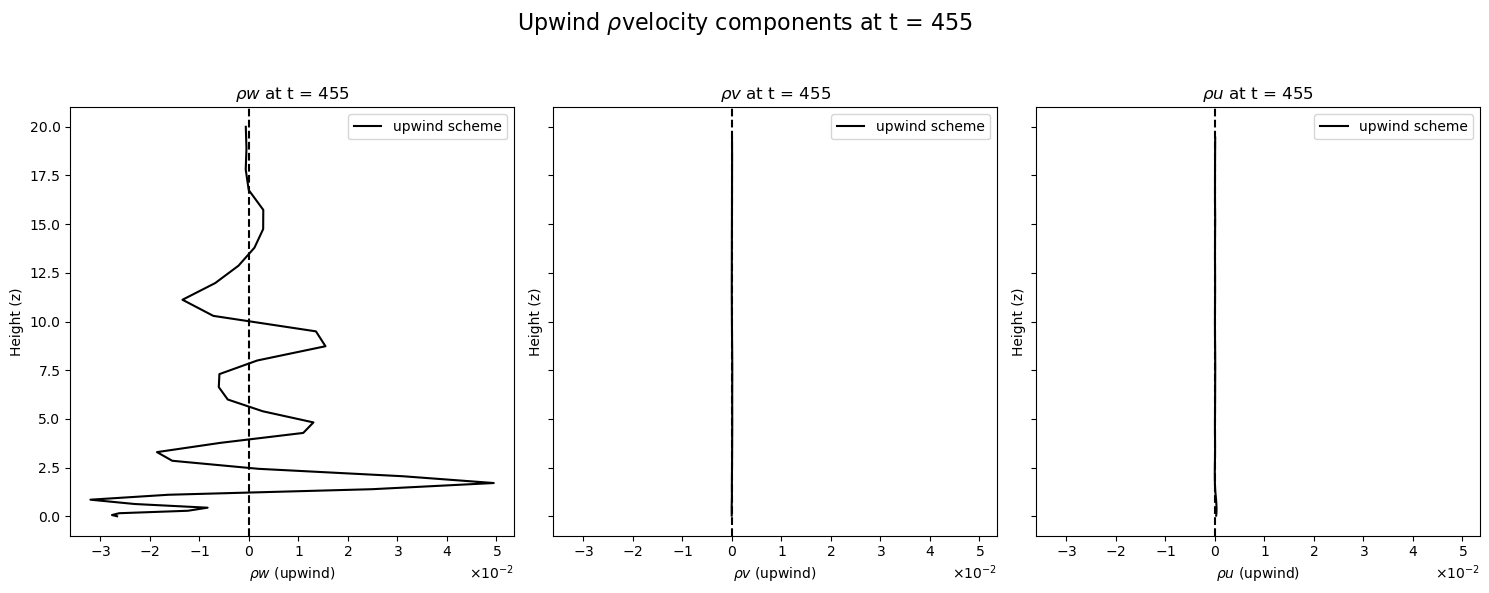

In [414]:
def plot_ddz_rho_w_ax():

    zf_coord = data['zf']

    ax = plt.gca()
    ax.plot(ddz_w_horiz_mean, zf_coord, color='black', label='upwind scheme')
    ax.axvline(0, color='black', linestyle='dashed')
    ax.set_ylabel("Height (z)")
    ax.set_xlabel(r"$\rho w$ (upwind)")
    ax.set_title(f"$\\rho w$ at t = {t}")
    apply_scientific_notation([ax])
    ax.legend()
    return ax


def plot_ddz_rho_v_ax():

    zh_coord = data['zh']

    ax = plt.gca()
    ax.plot(ddz_v_horiz_mean, zh_coord, color='black', label='upwind scheme')
    ax.axvline(0, color='black', linestyle='dashed')
    ax.set_ylabel("Height (z)")
    ax.set_xlabel(r"$\rho v$ (upwind)")
    ax.set_title(f"$\\rho v$ at t = {t}")
    apply_scientific_notation([ax])
    ax.legend()
    return ax


def plot_ddz_rho_u_ax():

    zh_coord = data['zh']

    ax = plt.gca()
    ax.plot(ddz_u_horiz_mean, zh_coord, color='black', label='upwind scheme')
    ax.axvline(0, color='black', linestyle='dashed')
    ax.set_ylabel("Height (z)")
    ax.set_xlabel(r"$\rho u$ (upwind)")
    ax.set_title(f"$\\rho u$ at t = {t}")
    apply_scientific_notation([ax])
    ax.legend()
    return ax


t = int(91 * 5)
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

plt.sca(axes[0])
plot_ddz_rho_w_ax()

plt.sca(axes[1])
plot_ddz_rho_v_ax()

plt.sca(axes[2])
plot_ddz_rho_u_ax()

axes[0].set_ylabel("Height (z)")

MatchAxisLimits(axes,'x')

plt.suptitle(f"Upwind $\\rho$velocity components at t = {t}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [404]:
#RHO TENDENCY
def ddt(t1, t2, dt): 
    # _ddt = (t2 - t1) / dt #forward difference
    _ddt = (t2 - t1) / (2*dt) #central difference
    return _ddt

rho1=data['rho'].isel(time=t-1,yh=y_slice,xh=x_slice).data
rho2=data['rho'].isel(time=t+1,yh=y_slice,xh=x_slice).data
ddt_rho=ddt(rho1,rho2,60)

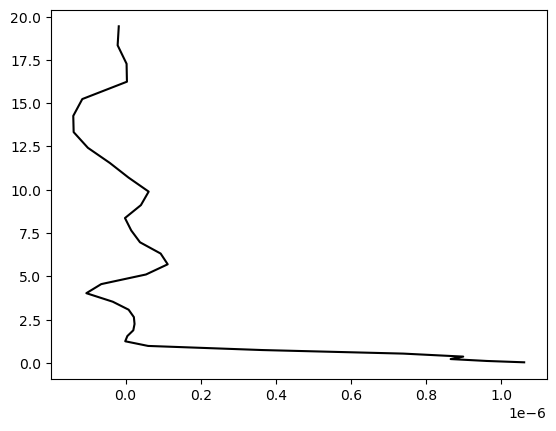

In [405]:
ddt_rho_horiz_mean=np.mean(ddt_rho,axis=(1,2))
plt.plot(ddt_rho_horiz_mean,data['zh'],color='black')

In [ ]:
#CALCULATING MASS CONTINUITY LHS

In [406]:
def GetBudgetTerm(data, t, velocity_name, z_slice, y_slice, x_slice):
    """
    Plot upwind horizontal average of the vertical derivative (central diff) of
    rho * velocity at a single timestep, subsetting according to staggered grids.
    
    Parameters:
    - data: xarray Dataset with 'rho', velocity variable, and 'zf'
    - t: integer index of the time step
    - velocity_name: 'u', 'v', or 'w'
    """

      # Grid dim mapping for staggered velocity fields
    vel_dims = {
        'u': {'z': 'zh', 'y': 'yh', 'x': 'xf', 'axis': 2},
        'v': {'z': 'zh', 'y': 'yf', 'x': 'xh', 'axis': 1},
        'w': {'z': 'zf', 'y': 'yh', 'x': 'xh', 'axis': 0}
    }
    
    dims = vel_dims[velocity_name]
    
    # Subset velocity and rho appropriately
    vel = data[velocity_name].isel(
        time=t,
        **{dims['y']: y_slice, dims['x']: x_slice}
    )
    
    rho = data['rho'].isel(
        time=t,
        yh=y_slice, xh=x_slice #zh=z_slice, 
    )
    
    flux = upwind_mass_flux(rho, vel, axis=dims['axis'])  # flux at faces

    if velocity_name=='w':
        zcoords=data['zf']
    else:
        zcoords=data['zh']

    # Compute vertical derivative on flux at faces
    if velocity_name=='w':
        flux_grad = Ddz_3DStretch_faces(flux.data, zcoords)
    elif velocity_name=='v':
        flux_grad = Ddy_faces(flux.data, dy=250)
    elif velocity_name=='u':
        flux_grad = Ddx_faces(flux.data, dx=250)
    
    return flux_grad

y_slice = slice(300, 500)
x_slice = slice(1100, 1300)

In [407]:
t=int(91*5)
velocity_name='w'
ddz_w=GetBudgetTerm(data,t,velocity_name,z_slice,y_slice,x_slice)

t=int(91*5)
velocity_name='v'
ddy_v=GetBudgetTerm(data,t,velocity_name,z_slice,y_slice,x_slice)

t=int(91*5)
velocity_name='u'
ddx_u=GetBudgetTerm(data,t,velocity_name,z_slice,y_slice,x_slice)

In [408]:
ddz_w_interp = xr.DataArray(
    ddz_w,
    coords={
        'zf': data['zf'],                 # vertical coordinate, not sliced
        'yh': data['yh'].isel(yh=y_slice),  # sliced accordingly
        'xh': data['xh'].isel(xh=x_slice)   # sliced accordingly
    },
    dims=('zf', 'yh', 'xh'),
    name='ddz_w'
).interp(zf=data['zh']).data

In [409]:
combined=ddt_rho+(ddz_w_interp+ddy_v+ddx_u)
mean_xy = np.mean(combined, axis=(1,2))  # mean over x,y -> function of z
mean_zy = np.mean(combined, axis=(0,1))  # mean over z,y -> function of x
mean_zx = np.mean(combined, axis=(0,2))  # mean over z,x -> function of y

mean_z = np.mean(combined, axis=0)   # mean over z -> 2D y,x
mean_y = np.mean(combined, axis=1)   # mean over y -> 2D z,x
mean_x = np.mean(combined, axis=2)   # mean over x -> 2D z,y


In [410]:
import matplotlib.pyplot as plt
import numpy as np

# 1D line plots for means over pairs of dims

def plot_mean_vs_z(mean_xy, zh):
    fig, ax = plt.subplots()
    ax.plot(mean_xy, zh)
    ax.set_title('Mean over X and Y (vs Z)')
    ax.set_xlabel('Value')
    ax.set_ylabel('z (km)')
    return fig, ax

def plot_mean_vs_x(mean_zy, xh):
    fig, ax = plt.subplots()
    ax.plot(xh, mean_zy)
    ax.set_title('Mean over Z and Y (vs X)')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('Value')
    return fig, ax

def plot_mean_vs_y(mean_zx, yh):
    fig, ax = plt.subplots()
    ax.plot(mean_zx, yh)
    ax.set_title('Mean over Z and X (vs Y)')
    ax.set_xlabel('y (km)')
    ax.set_ylabel('Value')
    return fig, ax

# 2D contourf plots for means over single dims

def contourf_mean_xy(mean_z, xh, yh, eps=1e-3):
    out = mean_z.copy()
    out = np.where(np.abs(out) <= eps, np.nan, out)
    vmax = np.nanmax(np.abs(out))
    levels = np.linspace(-vmax, vmax, 51)
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(xh, yh, out, levels=levels, cmap='seismic', extend='both')
    fig.colorbar(contour, ax=ax)
    ax.set_title(f'Mean over Z (Y vs X)\n(White = |val| ≤ {eps})')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    return fig, ax

def contourf_mean_xz(mean_y, xh, zh, eps=1e-3):
    out = mean_y.copy()
    out = np.where(np.abs(out) <= eps, np.nan, out)
    vmax = np.nanmax(np.abs(out))
    levels = np.linspace(-vmax, vmax, 51)
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(xh, zh, out, levels=levels, cmap='seismic', extend='both')
    fig.colorbar(contour, ax=ax)
    ax.set_title(f'Mean over Y (Z vs X)\n(White = |val| ≤ {eps})')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('z (km)')
    return fig, ax

def contourf_mean_yz(mean_x, yh, zh, eps=1e-3):
    out = mean_x.copy()
    out = np.where(np.abs(out) <= eps, np.nan, out)
    vmax = np.nanmax(np.abs(out))
    levels = np.linspace(-vmax, vmax, 51)
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(yh, zh, out, levels=levels, cmap='seismic', extend='both')
    fig.colorbar(contour, ax=ax)
    ax.set_title(f'Mean over X (Z vs Y)\n(White = |val| ≤ {eps})')
    ax.set_xlabel('y (km)')
    ax.set_ylabel('z (km)')
    return fig, ax


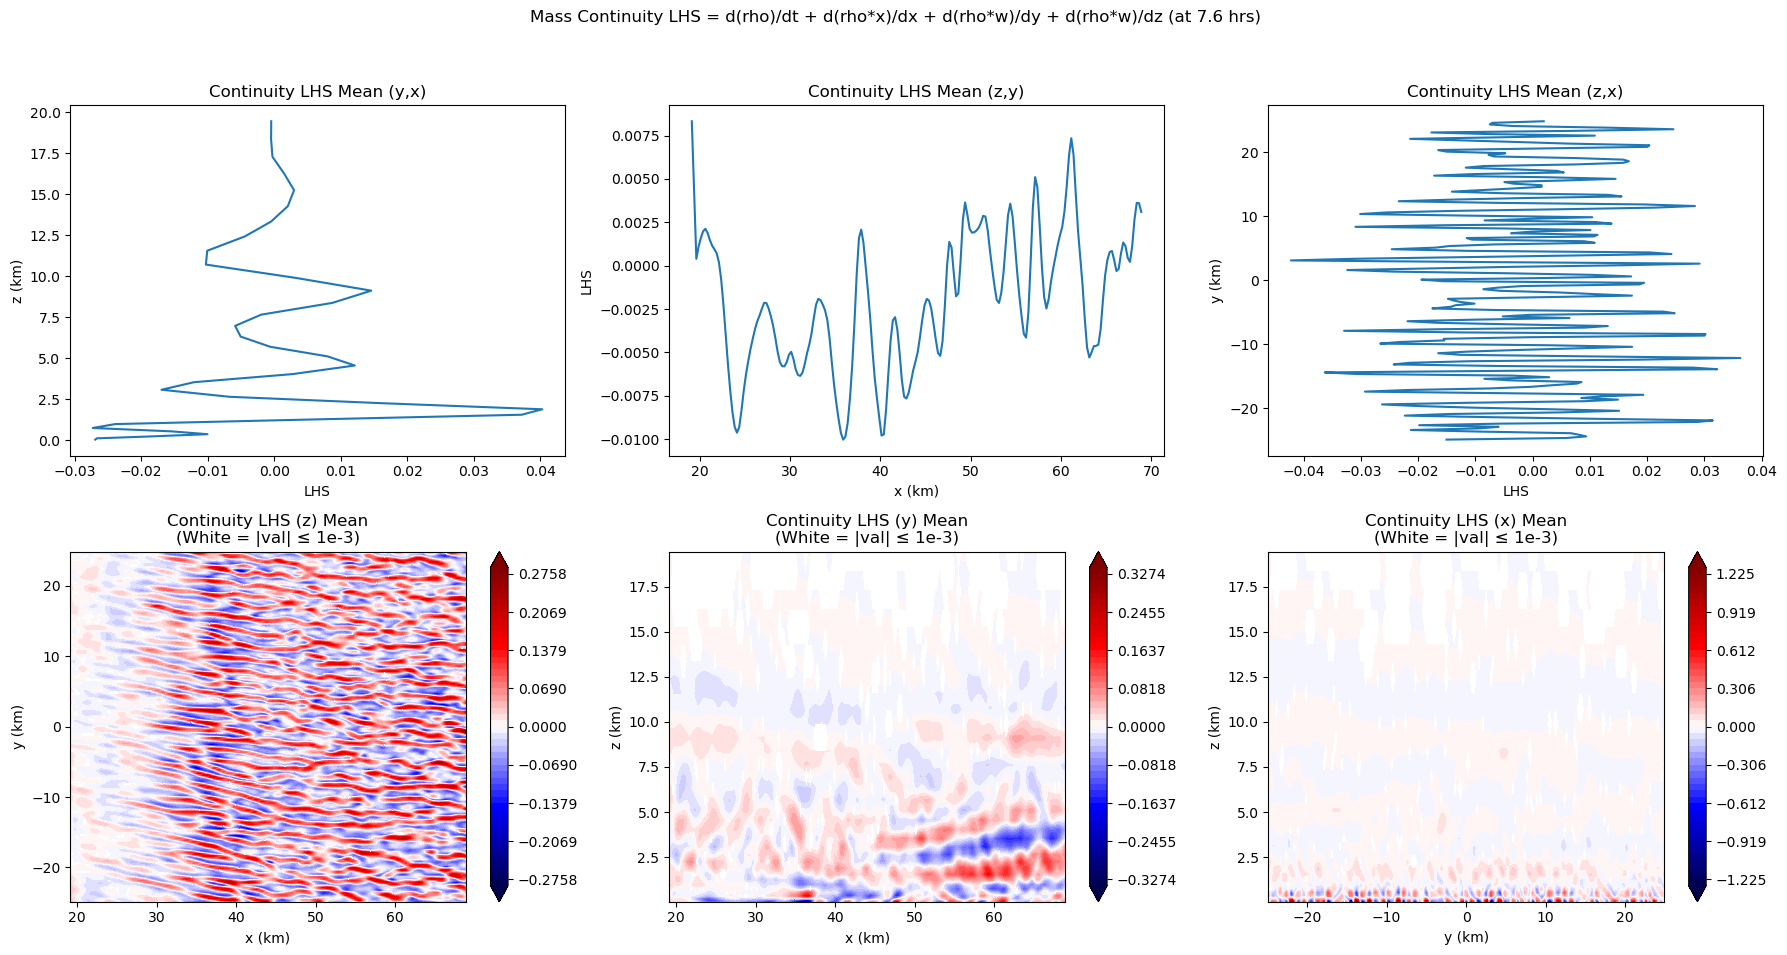

In [411]:
import matplotlib.pyplot as plt
import numpy as np

eps = 1e-3

fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 cols

# --------- Row 1: Line plots using precomputed means ---------
# mean_xy shape: (z,)
axs[0, 0].plot(mean_xy, data['zh'])
axs[0, 0].set(title='Continuity LHS Mean (y,x)', xlabel='LHS', ylabel='z (km)')

# mean_zy shape: (x,)
axs[0, 1].plot(data['xh'][x_slice], mean_zy)
axs[0, 1].set(title='Continuity LHS Mean (z,y)', xlabel='x (km)', ylabel='LHS')

# mean_zx shape: (y,)
axs[0, 2].plot(mean_zx, data['yh'][y_slice])
axs[0, 2].set(title='Continuity LHS Mean (z,x)', xlabel='LHS', ylabel='y (km)')

# --------- Row 2: Contour plots using precomputed means ---------
def prep_contour_from_array(data_2d, x_vals, y_vals, xlabel, ylabel, ax):
    # data_2d must be shape (len(y_vals), len(x_vals))
    # If shape mismatch, transpose:
    if data_2d.shape != (len(y_vals), len(x_vals)):
        data_2d = data_2d.T

    out = np.where(np.abs(data_2d) <= eps, np.nan, data_2d)
    vmax = np.nanmax(np.abs(out))
    levels = np.linspace(-vmax, vmax, 51)
    cont = ax.contourf(x_vals, y_vals, out, levels=levels, cmap='seismic', extend='both')
    fig.colorbar(cont, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

# mean_z: mean over z axis, shape (y,x)
prep_contour_from_array(mean_z, data['xh'][x_slice], data['yh'][y_slice], 'x (km)', 'y (km)', axs[1, 0])
axs[1, 0].set_title('Continuity LHS (z) Mean\n(White = |val| ≤ 1e-3)')

# mean_y: mean over y axis, shape (z,x)
prep_contour_from_array(mean_y, data['xh'][x_slice], data['zh'], 'x (km)', 'z (km)', axs[1, 1])
axs[1, 1].set_title('Continuity LHS (y) Mean\n(White = |val| ≤ 1e-3)')

# mean_x: mean over x axis, shape (z,y)
prep_contour_from_array(mean_x, data['yh'][y_slice], data['zh'], 'y (km)', 'z (km)', axs[1, 2])
axs[1, 2].set_title('Continuity LHS (x) Mean\n(White = |val| ≤ 1e-3)')

hrs = np.round(data['time'][t].item()/1e9/60**2, 1)
plt.suptitle(f'Mass Continuity LHS = d(rho)/dt + d(rho*x)/dx + d(rho*w)/dy + d(rho*w)/dz (at {hrs} hrs)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
